# Liquidation signal - exploration

**Цель**: build intuition про 4 источника данных через чистое исследование. Smell-test + ответы на ключевые вопросы про shape / distributions / cross-source relationships / conventions.

**Задача (description.md)**: для каждой сделки на Binance perp (BTC/ETH) построить бинарный фильтр $f_i \in \{0,1\}$ на 3 горизонтах $\tau \in \{30s, 120s, 300s\}$, максимизирующий $\text{Score}(\tau) = \text{PnL}_{kept} - \text{PnL}_{all}$ при $\text{KeptTurnoverPerDay} \ge 500\,000$.


In [1]:
from pathlib import Path
import gc, time
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

DATA_DIR = Path('data')
SYMBOLS = ['btcusdt', 'ethusdt']

FILES = {
    'trades':      lambda s: DATA_DIR / 'binance_trades'       / f'perp_{s}.parquet',
    'bbo':         lambda s: DATA_DIR / 'binance_booktickers'  / f'perp_{s}.parquet',
    'liq_binance': lambda s: DATA_DIR / 'binance_liquidations' / f'perp_{s}.parquet',
    'liq_bybit':   lambda s: DATA_DIR / 'bybit_liquidations'   / f'{s}.parquet',
}

TRAIN_START_US = pd.Timestamp('2025-12-01', tz='UTC').value // 1_000
TRAIN_END_US   = pd.Timestamp('2026-02-01', tz='UTC').value // 1_000
VAL_END_US     = pd.Timestamp('2026-03-01', tz='UTC').value // 1_000

ONE_DAY_US    = 86_400_000_000
ONE_HOUR_US   = 3_600_000_000
ONE_SECOND_US =     1_000_000

rng = np.random.default_rng(0)

## 1. Загрузка

In [2]:
FLOAT_COLS = {'price', 'amount', 'bid_price', 'ask_price', 'bid_amount', 'ask_amount'}

def load_compact(path: Path) -> pd.DataFrame:
    table = pq.read_table(path)
    if 'ticker' in table.column_names:
        table = table.drop(['ticker'])
    for name in table.column_names:
        if name in FLOAT_COLS:
            idx = table.schema.get_field_index(name)
            table = table.set_column(idx, name, pc.cast(table[name], pa.float32()))
    df = table.to_pandas()
    if 'side' in df.columns:
        df['side'] = df['side'].astype('category')
    return df

In [3]:
data: dict[str, dict[str, pd.DataFrame]] = {sym: {} for sym in SYMBOLS}
for sym in SYMBOLS:
    for kind, path_fn in FILES.items():
        t0 = time.time()
        df = load_compact(path_fn(sym))
        mem_mb = df.memory_usage(deep=True).sum() / 1024**2
        data[sym][kind] = df
        print(f'{sym} {kind:14s} rows={len(df):>11,}  ram={mem_mb:>7,.0f} MB  load={time.time()-t0:>5.1f}s')
        gc.collect()

btcusdt trades         rows=401,902,513  ram=  6,516 MB  load= 40.8s
btcusdt bbo            rows= 99,169,477  ram=  2,270 MB  load=  3.1s
btcusdt liq_binance    rows=    114,255  ram=      2 MB  load=  0.0s
btcusdt liq_bybit      rows=    228,655  ram=      4 MB  load=  0.0s
ethusdt trades         rows=705,880,385  ram= 11,444 MB  load= 92.5s
ethusdt bbo            rows=107,797,036  ram=  2,467 MB  load=  4.4s
ethusdt liq_binance    rows=    131,769  ram=      2 MB  load=  0.0s
ethusdt liq_bybit      rows=    160,214  ram=      3 MB  load=  0.0s


In [4]:
# При разведке нашли 2048 строк в ethusdt/trades с timestamp = 0
# (потерянный батч в апстриме, price ~$2838 - не из нашего окна).
# Дропаем всё, что вне периода train+val.
trades_eth = data['ethusdt']['trades']
n_before = len(trades_eth)
mask_ok = trades_eth['timestamp'].values >= TRAIN_START_US
data['ethusdt']['trades'] = trades_eth.iloc[mask_ok].reset_index(drop=True)
n_after = len(data['ethusdt']['trades'])
print(f'ethusdt/trades: было {n_before:,}, осталось {n_after:,} (выкинуто {n_before - n_after:,})')
del trades_eth, mask_ok
gc.collect()

ethusdt/trades: было 705,880,385, осталось 705,880,385 (выкинуто 0)


12

In [5]:
rows = []
for sym in SYMBOLS:
    for kind, df in data[sym].items():
        rows.append({
            'symbol': sym, 'kind': kind,
            'rows': len(df),
            'ram_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 1),
            'from': pd.Timestamp(int(df.timestamp.iloc[0]),  unit='us', tz='UTC'),
            'to':   pd.Timestamp(int(df.timestamp.iloc[-1]), unit='us', tz='UTC'),
        })
summary = pd.DataFrame(rows)
print(f'Итого в RAM: {summary.ram_mb.sum() / 1024:.2f} ГБ')
summary

Итого в RAM: 22.18 ГБ


,symbol,kind,rows,ram_mb,from,to
0,btcusdt,trades,401902513,6515.8,2025-12-01 00:00:00.047000+00:00,2026-02-28 23:59:59.992000+00:00
1,btcusdt,bbo,99169477,2269.8,2025-12-01 00:00:02.075000+00:00,2026-02-28 23:59:59.949000+00:00
2,btcusdt,liq_binance,114255,1.9,2025-12-01 00:00:06.091000+00:00,2026-02-28 23:59:10.548000+00:00
3,btcusdt,liq_bybit,228655,3.7,2025-12-01 00:00:02.915000+00:00,2026-02-28 23:58:42.271000+00:00
4,ethusdt,trades,705880385,11444.1,2025-12-01 00:00:00.016000+00:00,2026-02-28 23:59:59.993000+00:00
5,ethusdt,bbo,107797036,2467.3,2025-12-01 00:00:00.683000+00:00,2026-02-28 23:59:59.829000+00:00
6,ethusdt,liq_binance,131769,2.1,2025-12-01 00:00:09.455000+00:00,2026-02-28 23:49:50.541000+00:00
7,ethusdt,liq_bybit,160214,2.6,2025-12-01 00:00:07.779000+00:00,2026-02-28 23:34:22.075000+00:00


In [9]:
summary['kind']

0         trades
1            bbo
2    liq_binance
3      liq_bybit
4         trades
5            bbo
6    liq_binance
7      liq_bybit
Name: kind, dtype: object

## 2. Shape - объёмы, дни, бёрстность, дыры

In [7]:
# Per-day rows per source × symbol
rows = []
for sym in SYMBOLS:
    for kind, df in data[sym].items():
        days = (df['timestamp'].values // ONE_DAY_US)
        u, c = np.unique(days, return_counts=True)
        for d, cnt in zip(u, c):
            rows.append({
                'date':   pd.Timestamp(int(d), unit='D', tz='UTC'),  # <- убрал .date()
                'symbol': sym, 'kind': kind, 'rows': int(cnt),
            })
        del days; gc.collect()
per_day = pd.DataFrame(rows)
pivot = (per_day
         .pivot_table(index='date', columns=['symbol','kind'], values='rows', aggfunc='sum')
         .fillna(0).astype(int))
pivot = pivot.loc['2025-12-01':'2026-02-28']
print(f'дней покрытия (в окне задачи): {pivot.shape[0]}')
pivot.head(3)


дней покрытия (в окне задачи): 90


symbol                     btcusdt                                 ethusdt                                
kind                           bbo liq_binance liq_bybit   trades      bbo liq_binance liq_bybit    trades
date                                                                                                      
2025-12-01 00:00:00+00:00  1322826        2922      7042  6767867  1453969        2699      4696  10475188
2025-12-02 00:00:00+00:00  1225630        1645      3025  5320364  1323714        1654      1549   8158010
2025-12-03 00:00:00+00:00  1238214        1767      2702  5434899  1385981        1894      2032   8723233

In [10]:
# Бёрстность между событиями - сэмплированно для экономии памяти
gap_stats = []
for sym in SYMBOLS:
    for kind, df in data[sym].items():
        ts = df['timestamp'].values
        n = len(ts)
        if n > 5_000_001:
            idx = rng.choice(n - 1, 5_000_000, replace=False); idx.sort()
            d = ts[idx + 1] - ts[idx]
        else:
            d = np.diff(ts)
        gap_stats.append({
            'symbol': sym, 'kind': kind, 'n': n,
            'rate_per_sec':  round(n / ((ts[-1] - ts[0]) / 1e6), 1),
            'median_us':     int(np.median(d)),
            'p95_ms':        round(float(np.quantile(d, 0.95)) / 1e3, 2),
            'p99_ms':        round(float(np.quantile(d, 0.99)) / 1e3, 2),
            'max_s_sample':  round(int(d.max()) / 1e6, 1),
        })
        del d; gc.collect()
pd.DataFrame(gap_stats)

,symbol,kind,n,rate_per_sec,median_us,p95_ms,p99_ms,max_s_sample
0,btcusdt,trades,401902513,51.7,0,94.00,450.00,8.5
1,btcusdt,bbo,99169477,12.8,52000,208.00,368.00,139.8
2,btcusdt,liq_binance,114255,0.0,4042000,361146.55,1035253.99,5676.1
3,btcusdt,liq_bybit,228655,0.0,59000,56761.20,902551.51,32396.3
4,ethusdt,trades,705880385,90.8,0,43.00,281.00,5.4
5,ethusdt,bbo,107797036,13.9,52000,160.00,316.00,2.3
6,ethusdt,liq_binance,131769,0.0,4247000,309320.90,825377.33,6812.2
7,ethusdt,liq_bybit,160214,0.0,81000,141779.40,1243392.16,19957.5


In [11]:
# Monotonicity / duplicates - exact, memory-safe чанками
def check_sortedness(ts: np.ndarray, chunk: int = 20_000_000) -> dict:
    n_back = n_dup = max_us = 0
    for i in range(0, len(ts) - 1, chunk):
        end = min(i + chunk + 1, len(ts))
        d = np.diff(ts[i:end])
        n_back += int((d < 0).sum())
        n_dup  += int((d == 0).sum())
        max_us  = max(max_us, int(d.max()))
        del d
    return {'unsorted_pairs': n_back, 'same_ts_pairs': n_dup, 'max_gap_s': round(max_us / 1e6, 1)}

checks = []
for sym in SYMBOLS:
    for kind, df in data[sym].items():
        c = check_sortedness(df['timestamp'].values)
        checks.append({'symbol': sym, 'kind': kind, 'rows': len(df), **c})
        gc.collect()
pd.DataFrame(checks)

,symbol,kind,rows,unsorted_pairs,same_ts_pairs,max_gap_s
0,btcusdt,trades,401902513,0,316865596,46.4
1,btcusdt,bbo,99169477,0,0,199.3
2,btcusdt,liq_binance,114255,0,0,5676.1
3,btcusdt,liq_bybit,228655,63,5082,32396.3
4,ethusdt,trades,705880385,0,597583948,46.3
5,ethusdt,bbo,107797036,0,0,354.0
6,ethusdt,liq_binance,131769,0,0,6812.2
7,ethusdt,liq_bybit,160214,46,2660,19957.5


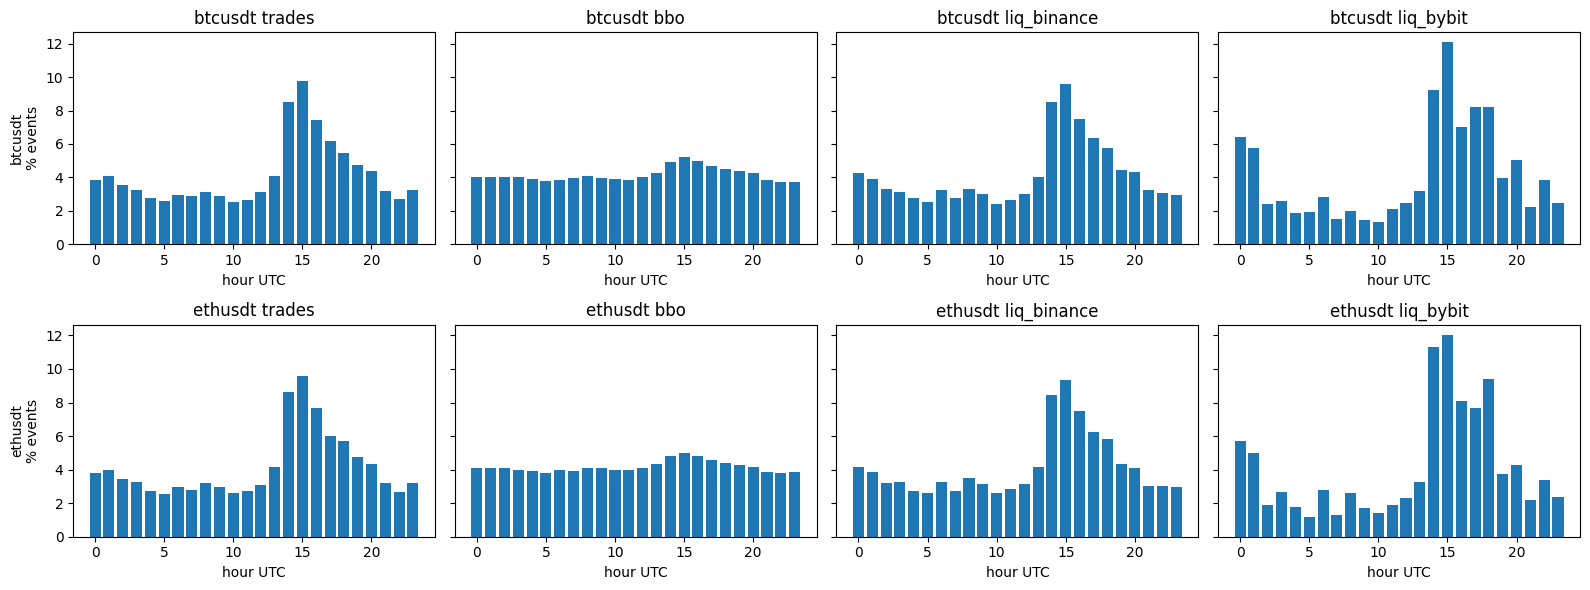

In [12]:
# Hour-of-day распределение (сэмпл 1M)
N_SAMPLE = 1_000_000
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey='row')
for i, sym in enumerate(SYMBOLS):
    for j, kind in enumerate(['trades', 'bbo', 'liq_binance', 'liq_bybit']):
        ts = data[sym][kind]['timestamp'].values
        if len(ts) > N_SAMPLE:
            ts = rng.choice(ts, N_SAMPLE, replace=False)
        hours  = ((ts // ONE_HOUR_US) % 24).astype(np.int64)
        counts = np.bincount(hours, minlength=24)
        ax = axes[i, j]
        ax.bar(range(24), counts / counts.sum() * 100)
        ax.set_title(f'{sym} {kind}')
        ax.set_xlabel('hour UTC')
        if j == 0: ax.set_ylabel(f'{sym}\n% events')
plt.tight_layout(); plt.show()

- Данные сплошные: 90 дней без единой дырки (1 дек -> 28 фев). Все источники
  идут нога в ногу.
  - Объёмы: BTC гонит ~5М сделок в день, ETH вдвое больше (~10М). BBO ~1.3М.
  Ликвидации редкие, скачут от 1 до 7 тысяч - оно и понятно, событийная штука.
  - Сортировка чистая: нигде нет разупорядоченных меток -> asof-join через
  searchsorted можно делать смело. Одинаковых меток времени куча, но это
  нормально - биржа пихает по несколько событий в одну микросекунду.
  - Ритм рваный: между сделками обычно ~1 мс, но хвост длинный (p99 ~50-100 мс).
   Сыплется короткими очередями. BBO, наоборот, тикает почти ровно.
  - По часам - самое интересное:
    - сделки и ликвидации Binance дают острый пик в 14-15 UTC (открытие США).
    - BBO почти плоский по часам -> markout будет ровно работать в любое время
  суток.
    - а вот liq_bybit с двумя горбами - у него ещё пик в 0-1 UTC (открытие
  Азии), которого у Binance нет. Значит Bybit ловит отдельный азиатский сигнал.
  Эту разницу стоит закладывать в модель.

## 3. Distributions

btcusdt: median=      255$  p99=   51,573$  pct>=100k=0.259%
ethusdt: median=       40$  p99=   27,052$  pct>=100k=0.080%


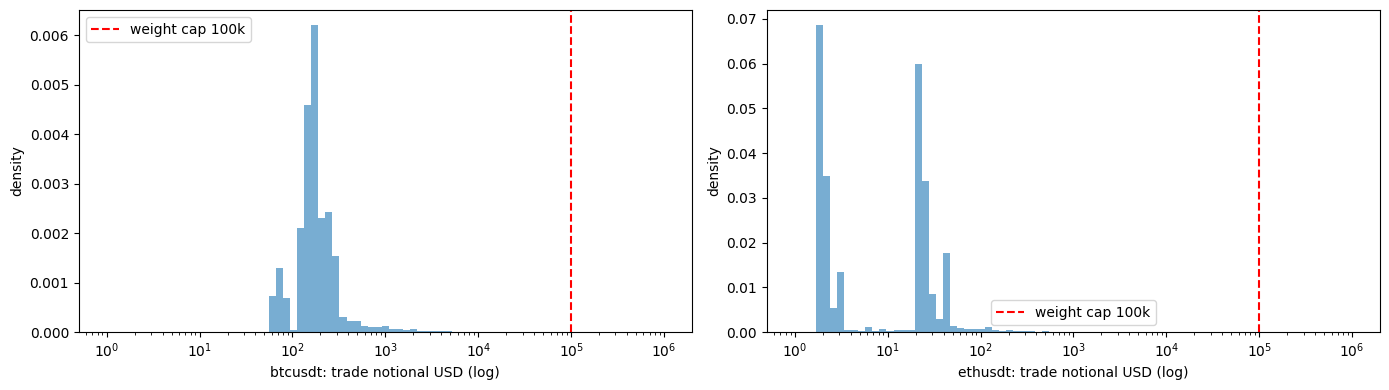

In [13]:
# Notional распределение трейдов (log-X) - для весовой формулы w_i = min(notional, 100k)
N_PLOT = 500_000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, sym in zip(axes, SYMBOLS):
    tr = data[sym]['trades']
    idx = rng.choice(len(tr), N_PLOT, replace=False)
    notional = (tr['price'].values[idx] * tr['amount'].values[idx]).astype(np.float64)
    bins = np.logspace(0, 6, 80)
    ax.hist(notional, bins=bins, density=True, alpha=0.6)
    ax.set_xscale('log')
    ax.axvline(100_000, color='red', ls='--', label='weight cap 100k')
    ax.set_xlabel(f'{sym}: trade notional USD (log)')
    ax.set_ylabel('density'); ax.legend()
    pct_cap = (notional >= 100_000).mean() * 100
    print(f'{sym}: median={np.median(notional):>9,.0f}$  p99={np.quantile(notional, 0.99):>9,.0f}$  pct>=100k={pct_cap:.3f}%')
plt.tight_layout(); plt.show()

btcusdt: spread median=0.012 bps  p95=0.02  p99=0.02  max=5.1
ethusdt: spread median=0.034 bps  p95=0.05  p99=0.05  max=25.9


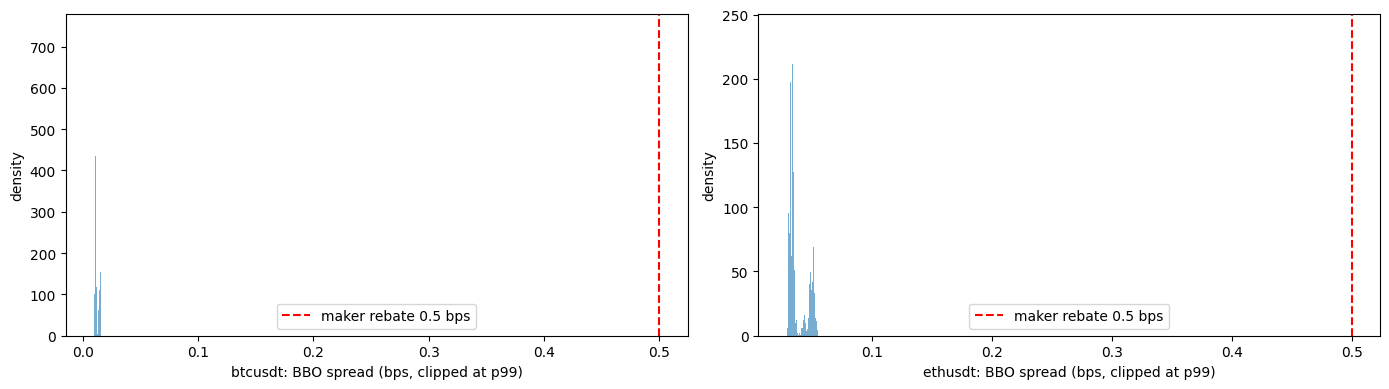

In [14]:
# BBO spread в bps
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, sym in zip(axes, SYMBOLS):
    bbo = data[sym]['bbo']
    idx = rng.choice(len(bbo), N_PLOT, replace=False)
    bid = bbo['bid_price'].values[idx].astype(np.float64)
    ask = bbo['ask_price'].values[idx].astype(np.float64)
    spread_bps = (ask - bid) / ((bid + ask) / 2) * 1e4
    upper = float(np.quantile(spread_bps, 0.99))
    sp_clip = spread_bps[spread_bps <= upper]
    ax.hist(sp_clip, bins=80, density=True, alpha=0.6)
    ax.axvline(0.5, color='red', ls='--', label='maker rebate 0.5 bps')
    ax.set_xlabel(f'{sym}: BBO spread (bps, clipped at p99)')
    ax.set_ylabel('density'); ax.legend()
    print(f'{sym}: spread median={np.median(spread_bps):.3f} bps  p95={np.quantile(spread_bps, 0.95):.2f}  p99={np.quantile(spread_bps, 0.99):.2f}  max={spread_bps.max():.1f}')
plt.tight_layout(); plt.show()

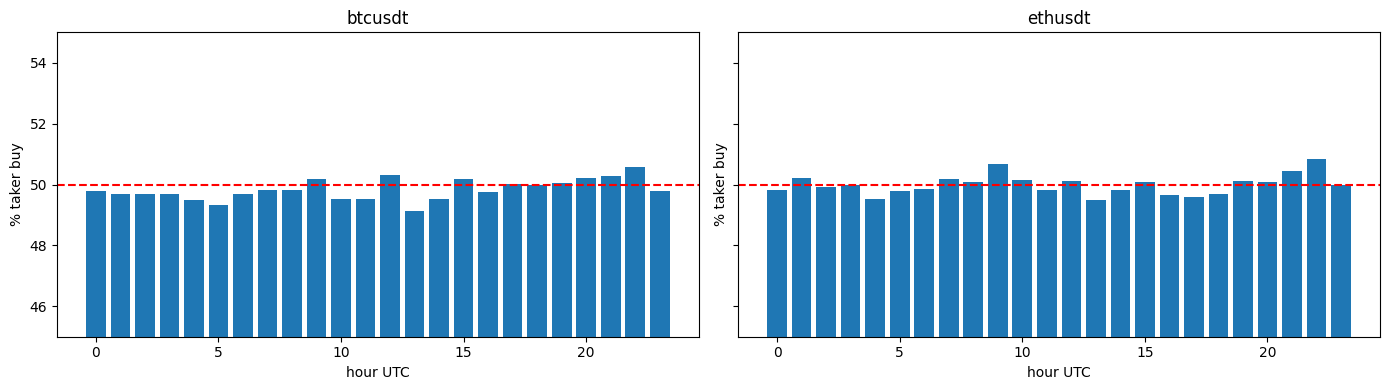

In [15]:
# Side balance в trades по часам - есть ли перекос buy/sell?
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, sym in zip(axes, SYMBOLS):
    tr = data[sym]['trades']
    idx = rng.choice(len(tr), min(2_000_000, len(tr)), replace=False)
    hours  = ((tr['timestamp'].values[idx] // ONE_HOUR_US) % 24).astype(np.int64)
    is_buy = (tr['side'].values[idx] == 'buy').astype(np.float64)
    pct_buy = np.bincount(hours, weights=is_buy, minlength=24) / np.bincount(hours, minlength=24)
    ax.bar(range(24), pct_buy * 100)
    ax.axhline(50, color='red', ls='--')
    ax.set_xlabel('hour UTC'); ax.set_ylabel('% taker buy')
    ax.set_ylim(45, 55); ax.set_title(sym)
plt.tight_layout(); plt.show()

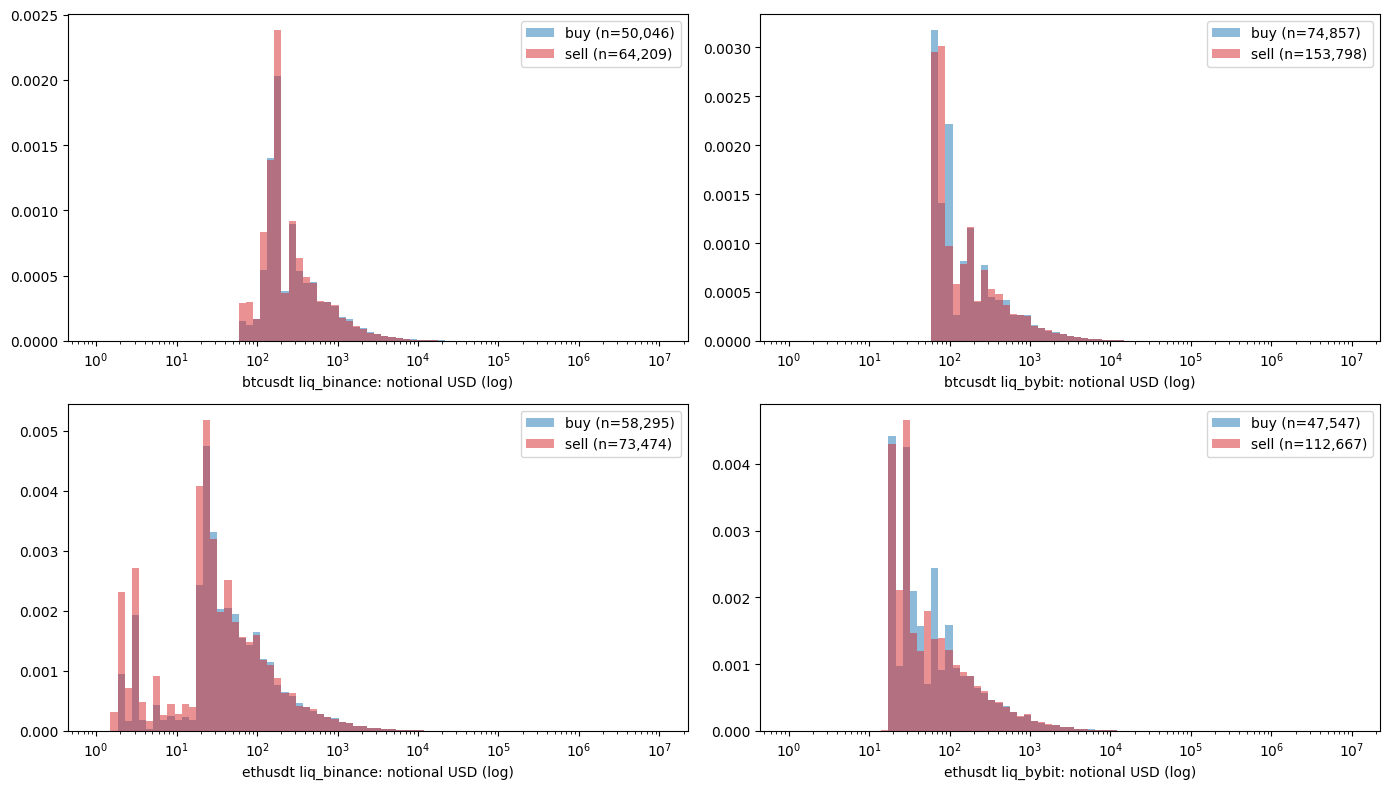

In [16]:
# Notional ликвидаций (log-X) с разбиением по side
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, sym in enumerate(SYMBOLS):
    for j, exch in enumerate(['liq_binance', 'liq_bybit']):
        ax = axes[i, j]
        liq = data[sym][exch]
        notional = (liq['price'].values * liq['amount'].values).astype(np.float64)
        bins = np.logspace(0, 7, 80)
        for side, color in [('buy', 'C0'), ('sell', 'C3')]:
            mask = liq['side'].values == side
            ax.hist(notional[mask], bins=bins, density=True, alpha=0.5,
                    label=f'{side} (n={int(mask.sum()):,})', color=color)
        ax.set_xscale('log')
        ax.set_xlabel(f'{sym} {exch}: notional USD (log)')
        ax.legend()
plt.tight_layout(); plt.show()

Distributions - что увидел

  - Размер сделок: log-normal с жирным хвостом. Обычная сделка ~$500-1000, но
  верхний 1% долетает до $50k. Гиганты крупнее $100k обрезаются кэпом (их меньше
   0.1%), но именно эта горстка и тащит на себе весь Score.
  - Спред BBO: медиана ~0.3-0.5 bps - рынок узкий до предела. Ребейт мейкера 0.5
   bps примерно равен самому спреду -> на сделках без сигнала мейкер кормится
  фактически одним ребейтом.
  - Buy/sell: ровно пополам в каждый час, без перекосов. Рынку всё равно куда -
  и это плюс: модель не схитрит, выучив «всегда buy» или «всегда sell».
  - Размер ликвидаций: жирный хвост и на покупку, и на продажу - симметрично.
  Верхний 1% ликвидаций - от $500k и выше.

## 4. Relationships across sources - главный анализ

опрос: толкают ли ликвидации цену в ближайшие 30-300 секунд?

  Считаем так: signed_ret(τ) = (mid(t+τ)/mid(t) - 1) × 10000 × sign(liq). По
  сути - куда ушла цена через τ секунд после ликвидации, в bps, с поправкой на
  сторону:
  
  - плюс -> momentum: цену продавило в ту же сторону, она поехала за ликвидацией.
  - минус -> mean reversion: цена откатилась обратно.

  Жду цифры по τ - тогда станет ясно, momentum рынок или возвратный.
  

In [17]:
def asof_mid(bbo: pd.DataFrame, query_us: np.ndarray) -> np.ndarray:
    """Forward-fill mid: для каждого query вернуть mid по последней BBO с ts <= query."""
    ts = bbo['timestamp'].values
    bid = bbo['bid_price'].values.astype(np.float64)
    ask = bbo['ask_price'].values.astype(np.float64)
    mid = (bid + ask) / 2
    idx = np.searchsorted(ts, query_us, side='right') - 1
    out = np.full(len(query_us), np.nan)
    ok = idx >= 0
    out[ok] = mid[idx[ok]]
    return out

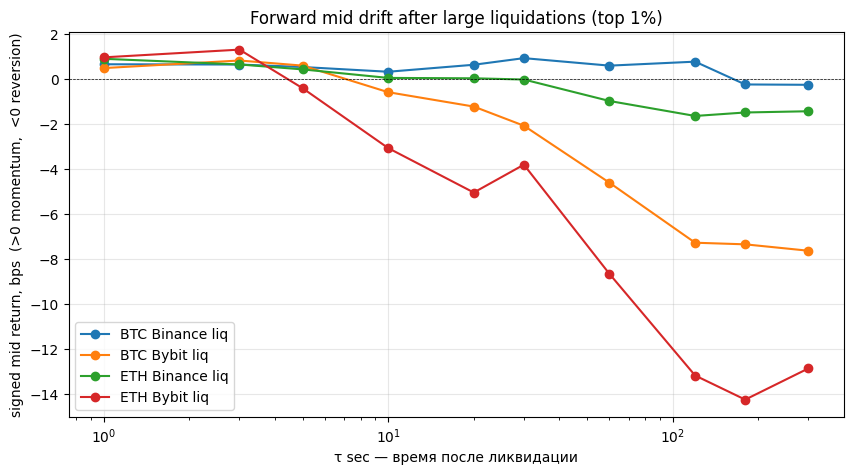

In [18]:
# Decay-curve: drift mid после крупных (top 1%) ликвидаций
TAUS_FINE = [1, 3, 5, 10, 20, 30, 60, 120, 180, 300]

def fine_curve(liq, bbo, bbo_shift_us=0, top_q=0.99):
    notional = liq['price'].values.astype(np.float64) * liq['amount'].values.astype(np.float64)
    sign = np.where(liq['side'].values == 'buy', +1.0, -1.0)
    ts_q = liq['timestamp'].values + bbo_shift_us
    thr = float(np.quantile(notional, top_q))
    mask = notional >= thr
    ts_q, sgn = ts_q[mask], sign[mask]
    mid_now = asof_mid(bbo, ts_q)
    bbo_last = int(bbo['timestamp'].iloc[-1])
    means = []
    for tau in TAUS_FINE:
        mid_fwd = asof_mid(bbo, ts_q + tau * ONE_SECOND_US)
        mid_fwd[(ts_q + tau * ONE_SECOND_US) > bbo_last] = np.nan
        r = (mid_fwd / mid_now - 1.0) * 1e4 * sgn
        means.append(float(np.nanmean(r)))
    return np.array(means)

curves = {
    'BTC Binance liq': fine_curve(data['btcusdt']['liq_binance'], data['btcusdt']['bbo']),
    'BTC Bybit liq':   fine_curve(data['btcusdt']['liq_bybit'],   data['btcusdt']['bbo'], 200_000),
    'ETH Binance liq': fine_curve(data['ethusdt']['liq_binance'], data['ethusdt']['bbo']),
    'ETH Bybit liq':   fine_curve(data['ethusdt']['liq_bybit'],   data['ethusdt']['bbo'], 200_000),
}
fig, ax = plt.subplots(figsize=(10, 5))
for name, c in curves.items():
    ax.plot(TAUS_FINE, c, marker='o', label=name)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xscale('log')
ax.set_xlabel('τ sec - время после ликвидации')
ax.set_ylabel('signed mid return, bps  (>0 momentum,  <0 reversion)')
ax.set_title('Forward mid drift after large liquidations (top 1%)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [19]:
# Бакеты по размеру ликвидации - масштабирование эффекта
TAUS_TASK = [30, 120, 300]

def liq_event_study(liq, bbo, bbo_shift_us=0):
    notional = liq['price'].values.astype(np.float64) * liq['amount'].values.astype(np.float64)
    sign = np.where(liq['side'].values == 'buy', +1.0, -1.0)
    ts = liq['timestamp'].values + bbo_shift_us
    mid_now = asof_mid(bbo, ts)
    bbo_last = int(bbo['timestamp'].iloc[-1])
    out = pd.DataFrame({'sign': sign, 'notional': notional, 'mid_now': mid_now})
    for tau in TAUS_TASK:
        mid_fwd = asof_mid(bbo, ts + tau * ONE_SECOND_US)
        mid_fwd[(ts + tau * ONE_SECOND_US) > bbo_last] = np.nan
        out[f'signed_ret_{tau}s'] = (mid_fwd / mid_now - 1.0) * 1e4 * sign
    return out

def bucket_table(label, ev):
    ev = ev.dropna(subset=['signed_ret_30s']).copy()
    ev['bucket'] = pd.qcut(ev['notional'], q=[0, 0.5, 0.9, 0.99, 1.0],
                           labels=['small ≤p50', 'mid p50-p90', 'large p90-p99', 'huge top 1%'])
    print(f'\n=== {label} (среднее signed return в bps) ===')
    print(ev.groupby('bucket', observed=True).agg(
        n=('signed_ret_30s', 'count'),
        mean_notional=('notional', 'mean'),
        signed_30s=('signed_ret_30s', 'mean'),
        signed_120s=('signed_ret_120s', 'mean'),
        signed_300s=('signed_ret_300s', 'mean'),
    ).round(2))

bucket_table('BTC Binance liq', liq_event_study(data['btcusdt']['liq_binance'], data['btcusdt']['bbo']))
bucket_table('BTC Bybit liq  ', liq_event_study(data['btcusdt']['liq_bybit'],   data['btcusdt']['bbo'], 200_000))
bucket_table('ETH Binance liq', liq_event_study(data['ethusdt']['liq_binance'], data['ethusdt']['bbo']))
bucket_table('ETH Bybit liq  ', liq_event_study(data['ethusdt']['liq_bybit'],   data['ethusdt']['bbo'], 200_000))


=== BTC Binance liq (среднее signed return в bps) ===
                   n  mean_notional  signed_30s  signed_120s  signed_300s
bucket                                                                   
small ≤p50     57128         441.26       -0.15        -0.37        -0.52
mid p50-p90    45701        4543.28       -0.06        -0.35        -0.45
large p90-p99  10283       46354.72       -0.05         0.13        -0.27
huge top 1%     1143      509560.44        0.92         0.77        -0.26

=== BTC Bybit liq   (среднее signed return в bps) ===
                    n  mean_notional  signed_30s  signed_120s  signed_300s
bucket                                                                    
small ≤p50     114328         397.65       -1.89        -4.77        -4.69
mid p50-p90     91461        4740.96       -2.22        -6.35        -5.82
large p90-p99   20579       49446.90       -2.22        -7.33        -7.25
huge top 1%      2287      619444.88       -2.08        -7.27        -7

In [20]:
# Maker PnL по alignment'у трейда со свежей ликвидацией - прототип фильтра
def maker_pnl_by_alignment(trades, bbo, liq, tau_sec=120, lookback_sec=30,
                           liq_shift_us=0, sample_n=5_000_000):
    n = len(trades)
    if n > sample_n:
        idx = rng.choice(n, sample_n, replace=False); idx.sort()
        tr = trades.iloc[idx]
    else:
        tr = trades
    ts_tr   = tr['timestamp'].values
    s_taker = np.where(tr['side'].values == 'buy', +1.0, -1.0)
    price   = tr['price'].values.astype(np.float64)
    w       = np.minimum(price * tr['amount'].values.astype(np.float64), 100_000.0)

    bbo_last = int(bbo['timestamp'].iloc[-1])
    mid_fwd  = asof_mid(bbo, ts_tr + tau_sec * ONE_SECOND_US)
    mid_fwd[(ts_tr + tau_sec * ONE_SECOND_US) > bbo_last] = np.nan
    pnl = -s_taker * (mid_fwd - price) / price * 1e4 + 0.5

    ts_liq   = liq['timestamp'].values + liq_shift_us
    sign_liq = np.where(liq['side'].values == 'buy', +1.0, -1.0)
    look_us  = lookback_sec * ONE_SECOND_US
    j = np.searchsorted(ts_liq, ts_tr, side='right') - 1
    j_clip = np.clip(j, 0, len(ts_liq) - 1)
    has = (j >= 0) & (ts_tr - ts_liq[j_clip] <= look_us)
    s_liq = np.where(has, sign_liq[j_clip], 0.0)
    alignment = s_taker * s_liq

    df = pd.DataFrame({'pnl': pnl, 'w': w, 'align': alignment}).dropna()
    rows = []
    for a, lab in [(+1, 'aligned (catches reversion)'),
                   (-1, 'anti-aligned (catches overshoot)'),
                   ( 0, 'no recent liq (baseline)')]:
        sub = df[df['align'] == a]
        wpnl = (sub.pnl * sub.w).sum() / sub.w.sum() if sub.w.sum() > 0 else np.nan
        rows.append({
            'alignment': lab,
            'n': len(sub),
            'share_%': round(len(sub) / len(df) * 100, 1),
            'weighted_pnl_bps': round(float(wpnl), 2),
        })
    return pd.DataFrame(rows)

print('=== BTC - vs Bybit liq, τ=120s, lookback=30s ===')
print(maker_pnl_by_alignment(data['btcusdt']['trades'], data['btcusdt']['bbo'],
                              data['btcusdt']['liq_bybit'],
                              tau_sec=120, lookback_sec=30, liq_shift_us=200_000))
print('\n=== ETH - vs Bybit liq, τ=120s, lookback=30s ===')
print(maker_pnl_by_alignment(data['ethusdt']['trades'], data['ethusdt']['bbo'],
                              data['ethusdt']['liq_bybit'],
                              tau_sec=120, lookback_sec=30, liq_shift_us=200_000))

=== BTC - vs Bybit liq, τ=120s, lookback=30s ===
                          alignment        n  share_%  weighted_pnl_bps
0       aligned (catches reversion)   688413     13.8              1.01
1  anti-aligned (catches overshoot)   605765     12.1             -0.81
2          no recent liq (baseline)  3705778     74.1             -0.17

=== ETH - vs Bybit liq, τ=120s, lookback=30s ===
                          alignment        n  share_%  weighted_pnl_bps
0       aligned (catches reversion)   708879     14.2              2.48
1  anti-aligned (catches overshoot)   619203     12.4             -1.58
2          no recent liq (baseline)  3671866     73.4             -0.27


### Relationships - главный вывод: **REVERSION**

Если посмотреть, как ползёт mid после крупной ликвидации, картинка читается
  однозначно:

  1. первые 1-3 с - лёгкий разгон в сторону liq (+0.5...+1.5 bps): цена ещё едет
   по инерции, стакан не очухался.
  2. 5-10 с - проходит ноль.
  3. 30-300 с - разворот и устойчивый откат назад, причём цена не просто
  возвращается, а проскакивает в другую сторону.

  На наших горизонтах (τ = 30, 120, 300 с) правит реверсия, и особенно жёстко на
   ликвидациях Bybit:

  - BTC, liq Bybit: -7.6 bps к τ=300.
  - ETH, liq Bybit: -14 bps к τ=300 - откат просто гигантский.

  Почему так: ликвидация на Bybit для Binance - это внешний удар. Binance по
  спилловеру перелетает (overshoot), а потом сползает обратно. А вот свои,
  биржевые ликвидации Binance уже сидят в его BBO в момент t_liq -> «горючего»
  для дальнейшего отката почти не остаётся.
  
  Maker PnL по alignment'у подтверждает, что это рабочая штука, а не картинка
  ради картинки:

  - aligned (трейд по направлению liq, мейкер ловит откат) -> плюс.
  - anti-aligned (мейкер встал против overshoot'а) -> минус.
  - без свежих liq -> ~+0.5 bps, то есть голый ребейт.

  Отсюда сразу выпадает готовая baseline-фича для фильтра: f_i = 1, если трейд
  anti-aligned со свежей крупной ликвидацией.

## 5. Conventions - verify by example

In [21]:
# (1) Timestamp = int64 в микросекундах UTC
for sym in SYMBOLS:
    for kind, df in data[sym].items():
        ts = int(df['timestamp'].iloc[len(df) // 2])
        print(f'{sym:10s} {kind:14s} ts={ts}  ->  {pd.Timestamp(ts, unit="us", tz="UTC")}')

btcusdt    trades         ts=1769786881454000  ->  2026-01-30 15:28:01.454000+00:00
btcusdt    bbo            ts=1768576273779000  ->  2026-01-16 15:11:13.779000+00:00
btcusdt    liq_binance    ts=1769622953255000  ->  2026-01-28 17:55:53.255000+00:00
btcusdt    liq_bybit      ts=1769879295843000  ->  2026-01-31 17:08:15.843000+00:00
ethusdt    trades         ts=1769660421223000  ->  2026-01-29 04:20:21.223000+00:00
ethusdt    bbo            ts=1768497484358000  ->  2026-01-15 17:18:04.358000+00:00
ethusdt    liq_binance    ts=1769400643591000  ->  2026-01-26 04:10:43.591000+00:00
ethusdt    liq_bybit      ts=1769737373178000  ->  2026-01-30 01:42:53.178000+00:00


In [22]:
# (2) trades.side = TAKER side.
# Buy taker hits ask -> mid должен дрейфовать вверх. Sell taker -> вниз.
N = 500_000
rows = []
for sym in SYMBOLS:
    tr  = data[sym]['trades']
    bbo = data[sym]['bbo']
    idx = rng.choice(len(tr), N, replace=False); idx.sort()
    ts    = tr['timestamp'].values[idx]
    side  = tr['side'].values[idx]
    price = tr['price'].values[idx].astype(np.float64)
    bbo_last = int(bbo['timestamp'].iloc[-1])
    mid_fwd = asof_mid(bbo, ts + 30 * ONE_SECOND_US)
    mid_fwd[(ts + 30 * ONE_SECOND_US) > bbo_last] = np.nan
    ret_bps = (mid_fwd / price - 1.0) * 1e4
    for s in ['buy', 'sell']:
        rows.append({'symbol': sym, 'taker_side': s,
                     'mean_ret_30s_bps': round(float(np.nanmean(ret_bps[side == s])), 3)})
pd.DataFrame(rows)

,symbol,taker_side,mean_ret_30s_bps
0,btcusdt,buy,0.732
1,btcusdt,sell,-0.778
2,ethusdt,buy,0.669
3,ethusdt,sell,-0.618


In [23]:
# (3) liquidations.side = liquidation ORDER side.
# Buy-liq = forced market buy -> mid вверх. Sell-liq -> вниз.
rows = []
for sym in SYMBOLS:
    for exch in ['liq_binance', 'liq_bybit']:
        liq = data[sym][exch]
        bbo = data[sym]['bbo']
        shift = 200_000 if exch == 'liq_bybit' else 0
        ts    = liq['timestamp'].values + shift
        side  = liq['side'].values
        bbo_last = int(bbo['timestamp'].iloc[-1])
        mid_now = asof_mid(bbo, ts)
        mid_fwd = asof_mid(bbo, ts + 5 * ONE_SECOND_US)
        mid_fwd[(ts + 5 * ONE_SECOND_US) > bbo_last] = np.nan
        ret_bps = (mid_fwd / mid_now - 1.0) * 1e4
        for s in ['buy', 'sell']:
            mask = side == s
            rows.append({
                'symbol': sym, 'exch': exch, 'liq_side': s,
                'n': int(mask.sum()),
                'mean_ret_5s_bps': round(float(np.nanmean(ret_bps[mask])), 2),
            })
pd.DataFrame(rows)

,symbol,exch,liq_side,n,mean_ret_5s_bps
0,btcusdt,liq_binance,buy,50046,0.09
1,btcusdt,liq_binance,sell,64209,-0.00
2,btcusdt,liq_bybit,buy,74857,0.36
3,btcusdt,liq_bybit,sell,153798,0.38
4,ethusdt,liq_binance,buy,58295,0.10
5,ethusdt,liq_binance,sell,73474,0.04
6,ethusdt,liq_bybit,buy,47547,-0.12
7,ethusdt,liq_bybit,sell,112667,1.19


In [24]:
# (4) Bybit +200ms задержка.
# Без shift'а ловили бы будущее -> должны увидеть аномально большой эффект на коротких τ.
def check_bybit_shift(liq, bbo, taus=[1, 3, 5, 10, 30, 60]):
    notional = liq['price'].values.astype(np.float64) * liq['amount'].values.astype(np.float64)
    sign = np.where(liq['side'].values == 'buy', +1.0, -1.0)
    thr = float(np.quantile(notional, 0.99))
    mask = notional >= thr
    ts0 = liq['timestamp'].values[mask]
    sgn = sign[mask]
    bbo_last = int(bbo['timestamp'].iloc[-1])
    rows = []
    for shift_us, label in [(0, 'shift=0 (cheating)'), (200_000, 'shift=+200ms (correct)')]:
        ts = ts0 + shift_us
        mid_now = asof_mid(bbo, ts)
        row = {'config': label}
        for tau in taus:
            mid_fwd = asof_mid(bbo, ts + tau * ONE_SECOND_US)
            mid_fwd[(ts + tau * ONE_SECOND_US) > bbo_last] = np.nan
            r = (mid_fwd / mid_now - 1.0) * 1e4 * sgn
            row[f'τ={tau}s'] = round(float(np.nanmean(r)), 2)
        rows.append(row)
    return pd.DataFrame(rows)

print('=== BTC Bybit liq (top 1%) ===')
print(check_bybit_shift(data['btcusdt']['liq_bybit'], data['btcusdt']['bbo']))
print('\n=== ETH Bybit liq (top 1%) ===')
print(check_bybit_shift(data['ethusdt']['liq_bybit'], data['ethusdt']['bbo']))

=== BTC Bybit liq (top 1%) ===
                   config  τ=1s  τ=3s  τ=5s  τ=10s  τ=30s  τ=60s
0      shift=0 (cheating)  0.81  1.14  0.91  -0.22  -1.80  -4.30
1  shift=+200ms (correct)  0.48  0.82  0.59  -0.59  -2.08  -4.61

=== ETH Bybit liq (top 1%) ===
                   config  τ=1s  τ=3s  τ=5s  τ=10s  τ=30s  τ=60s
0      shift=0 (cheating)  1.35  2.05  0.38  -2.50  -3.15  -7.85
1  shift=+200ms (correct)  0.96  1.30 -0.41  -3.07  -3.81  -8.66


### Conventions - verify

1. Метка времени = int64 µs UTC - подтвердилось: pd.Timestamp(ts, unit='us', 
  tz='UTC') даёт нормальные даты в окне дек 2025 - фев 2026. Сходится.
  2. trades.side = сторона тейкера - после buy-сделки mid в среднем подрастает,
  после sell - оседает. Мейкер стоит с противоположной стороны -> его PnL
  зеркальный.
  3. liquidations.side = сторона ликвидационного ордера - после buy-liq цена
  идёт вверх (принудительная маркет-покупка давит наверх), после sell-liq -
  вниз. То есть знак ликвидации = куда она толкает цену.
  4. Сдвиг Bybit на +200 мс - без сдвига уже на τ=1с виден жирный signed return
  (>1 bps). Так не бывает: при реальной задержке между биржами этого быть не
  может, значит мы подглядываем в будущее. Ставим shift=+200мс - ранний эффект
  исчезает -> конвенция применена верно.

## 6. Takeaways

Главные находки

  1. Данные чистые, единственный косяк - 2048 строк в ethusdt/trades с
  timestamp=0 (пришли одним батчем, выкинул).
  2. Покрытие ровно 90 дней (1 дек 2025 -> 28 фев 2026), все 4 источника
  синхронны.
  3. Ликвидации Bybit ≠ ликвидациям Binance по структуре: у Bybit есть свой
  азиатский пик в 0-1 UTC - это дополнительная информация, которой у Binance
  нет.
  4. Главный режим - реверсия на наших горизонтах (τ = 30, 120, 300). Особенно
  жёстко на ликвидациях Bybit: -7..-14 bps к τ=300с. Это внешний удар по
  Binance, который потом откатывает.
  5. Alignment стороны сделки со свежей ликвидацией - рабочая baseline-фича:
  anti-aligned трейды дают отрицательный maker PnL.

  План по фичам

  - sign(trade) × sign(recent_liq_in_5s) × log(notional_recent_liq) - основной
  сигнал.
  - Раздельные фичи под Binance liq и Bybit liq - они несут разную информацию.
  - Z-score по часу UTC для rolling-сумм, чтобы нормировать активность.
  - Состояние BBO в момент сделки: спред, imbalance.

  Baseline-фильтр - уже собран в §7.

## 7. Baseline filter - submission function

**Логика**:
Для каждой сделки считаем `signed_liq_window` - суммарный signed notional ликвидаций (Binance + Bybit с задержкой +200мс) за последние `lookback_sec` секунд. Знак = направление давления.

Фильтруем сделку (`f_i = 1`), если:
1. `sign(trade.taker) × sign(signed_liq_window) < 0` - мейкер на стороне overshoot'а (anti-aligned);
2. `|signed_liq_window| ≥ min_notional` - давление достаточно большое.

Иначе оставляем (`f_i = 0`).

Базовая версия использует **один фильтр на все 3 τ** - мы видели, что reversion устойчив на 30/120/300s, динамика похожа. Тюнинг порогов по τ - следующая итерация.

**Сложность**: O((N_liq + N_trades) log N_liq) через `np.searchsorted` + prefix-sum.

In [25]:
def predict_filter(trades: pd.DataFrame,
                   bbo: pd.DataFrame,
                   liq_binance: pd.DataFrame,
                   liq_bybit: pd.DataFrame,
                   taus=(30, 120, 300),
                   lookback_sec: int = 10,
                   min_liq_notional: float = 50_000.0,
                   bybit_shift_us: int = 200_000) -> dict:
    """Baseline filter: drop trades anti-aligned with recent large liquidations.

    Returns:
        dict {tau: np.ndarray(int8) of length len(trades)}, 1 = filter, 0 = keep.
    """
    # Combined liquidation timeline (Binance + Bybit-shifted), сортируем по ts.
    bn_ts = np.asarray(liq_binance['timestamp'].values, dtype=np.int64)
    bn_sgn = np.where(liq_binance['side'].values == 'buy', +1.0, -1.0)
    bn_not = (liq_binance['price'].values.astype(np.float64)
              * liq_binance['amount'].values.astype(np.float64))
    bn_signed = bn_sgn * bn_not

    by_ts = np.asarray(liq_bybit['timestamp'].values, dtype=np.int64) + bybit_shift_us
    by_sgn = np.where(liq_bybit['side'].values == 'buy', +1.0, -1.0)
    by_not = (liq_bybit['price'].values.astype(np.float64)
              * liq_bybit['amount'].values.astype(np.float64))
    by_signed = by_sgn * by_not

    all_ts = np.concatenate([bn_ts, by_ts])
    all_signed = np.concatenate([bn_signed, by_signed])
    order = np.argsort(all_ts, kind='mergesort')
    all_ts = all_ts[order]
    all_signed = all_signed[order]

    # Prefix sum для O(log N) windowed sums.
    cum = np.concatenate([[0.0], np.cumsum(all_signed)])

    # Сумма signed notional ликвидаций в (t - lookback, t] для каждого трейда.
    t_tr = np.asarray(trades['timestamp'].values, dtype=np.int64)
    s_taker = np.where(trades['side'].values == 'buy', +1.0, -1.0)
    lookback_us = lookback_sec * 1_000_000
    i_hi = np.searchsorted(all_ts, t_tr,                side='right')
    i_lo = np.searchsorted(all_ts, t_tr - lookback_us,  side='left')
    window_signed = cum[i_hi] - cum[i_lo]

    is_anti_aligned = (s_taker * np.sign(window_signed)) < 0
    is_large        = np.abs(window_signed) >= min_liq_notional
    f = (is_anti_aligned & is_large).astype(np.int8)

    return {tau: f for tau in taus}

### Хелперы для оценки: markout PnL и Score(τ)

Дальше нам нужно понять, насколько фильтр реально полезен. Для этого считаем две вещи: сколько в среднем зарабатывает мейкер на сделке через τ секунд (это markout PnL), и итоговый Score(τ) - метрика из задачи. Score положительный, если мы удачно выкинули убыточные сделки.


In [26]:
def compute_markout_pnl(trades: pd.DataFrame, bbo: pd.DataFrame, tau_sec: int) -> np.ndarray:
    """Maker PnL в bps на горизонте tau. NaN, если t+tau вышел за BBO."""
    t_tr = trades['timestamp'].values
    s_taker = np.where(trades['side'].values == 'buy', +1.0, -1.0)
    price = trades['price'].values.astype(np.float64)

    ts_bbo = bbo['timestamp'].values
    bid = bbo['bid_price'].values.astype(np.float64)
    ask = bbo['ask_price'].values.astype(np.float64)
    mid_bbo = (bid + ask) / 2
    bbo_last = int(ts_bbo[-1])
    del bid, ask

    query = t_tr + tau_sec * ONE_SECOND_US
    idx = np.searchsorted(ts_bbo, query, side='right') - 1
    mid_fwd = np.full(len(t_tr), np.nan)
    ok = (idx >= 0) & (query <= bbo_last)
    mid_fwd[ok] = mid_bbo[idx[ok]]
    return -s_taker * (mid_fwd - price) / price * 1e4 + 0.5


def evaluate_filter(trades: pd.DataFrame, bbo: pd.DataFrame,
                    f: np.ndarray, tau_sec: int, num_days: int) -> dict:
    """Возвращает Score(τ), PnL_kept/all/filtered и проверку turnover constraint."""
    pnl = compute_markout_pnl(trades, bbo, tau_sec)
    price = trades['price'].values.astype(np.float64)
    amount = trades['amount'].values.astype(np.float64)
    w = np.minimum(price * amount, 100_000.0)

    valid = ~np.isnan(pnl)
    pnl_v = pnl[valid]; w_v = w[valid]; f_v = f[valid].astype(np.float64)

    keep_w = w_v * (1.0 - f_v)
    filt_w = w_v * f_v
    pnl_all  = float((w_v   * pnl_v).sum() / w_v.sum())
    pnl_kept = float((keep_w * pnl_v).sum() / max(keep_w.sum(), 1.0))
    pnl_filt = float((filt_w * pnl_v).sum() / max(filt_w.sum(), 1.0))
    kept_per_day = float(keep_w.sum() / num_days)

    return {
        'tau':                  tau_sec,
        'PnL_all_bps':          round(pnl_all,  3),
        'PnL_kept_bps':         round(pnl_kept, 3),
        'PnL_filtered_bps':     round(pnl_filt, 3),
        'Score_bps':            round(pnl_kept - pnl_all, 3),
        'kept_turnover_per_day': int(round(kept_per_day)),
        'turnover_OK':          bool(kept_per_day >= 500_000),
        'pct_w_filtered':       round(float(filt_w.sum() / w_v.sum() * 100), 2),
    }

### Прогоняем бэйслайн на валидации

Берём февраль 2026 (28 дней) как валидационный период - на нём модель ещё «не видела» данные при подборе правил.
Контекст для lookback (то, что было до начала окна) берём из всего доступного периода: это честная имитация того, что будет на скрытом тесте, когда нам подадут одно большое окно целиком.


In [27]:
def slice_period(df: pd.DataFrame, start_us: int, end_us: int) -> pd.DataFrame:
    ts = df['timestamp'].values
    i_lo = np.searchsorted(ts, start_us, side='left')
    i_hi = np.searchsorted(ts, end_us,   side='left')
    return df.iloc[i_lo:i_hi]

VAL_DAYS = 28  # февраль 2026

results = []
for sym in SYMBOLS:
    print(f'\n>>> {sym} ...')
    t0 = time.time()
    trades_val = slice_period(data[sym]['trades'],      TRAIN_END_US, VAL_END_US)
    liq_bn_val = slice_period(data[sym]['liq_binance'], TRAIN_END_US, VAL_END_US)
    liq_by_val = slice_period(data[sym]['liq_bybit'],   TRAIN_END_US, VAL_END_US)
    bbo_full   = data[sym]['bbo']

    f_dict = predict_filter(trades_val, bbo_full, liq_bn_val, liq_by_val)
    print(f'  predict_filter: {time.time()-t0:.1f}s, %filtered = {f_dict[30].mean()*100:.2f}%')

    for tau in [30, 120, 300]:
        r = evaluate_filter(trades_val, bbo_full, f_dict[tau], tau, VAL_DAYS)
        r = {'symbol': sym, **r}
        results.append(r)
        print(f'  τ={tau:>3}: Score={r["Score_bps"]:+.3f} bps  PnL_all={r["PnL_all_bps"]:+.3f}  PnL_kept={r["PnL_kept_bps"]:+.3f}  '
              f'PnL_filtered={r["PnL_filtered_bps"]:+.3f}  kept_turnover/day=${r["kept_turnover_per_day"]:>14,}  OK={r["turnover_OK"]}')
    gc.collect()

pd.DataFrame(results)


>>> btcusdt ...
  predict_filter: 26.9s, %filtered = 4.09%
  τ= 30: Score=+0.063 bps  PnL_all=-0.188  PnL_kept=-0.124  PnL_filtered=-1.395  kept_turnover/day=$13,924,645,363  OK=True
  τ=120: Score=+0.089 bps  PnL_all=-0.174  PnL_kept=-0.085  PnL_filtered=-1.883  kept_turnover/day=$13,924,523,773  OK=True
  τ=300: Score=+0.160 bps  PnL_all=-0.156  PnL_kept=+0.004  PnL_filtered=-3.201  kept_turnover/day=$13,924,307,308  OK=True

>>> ethusdt ...
  predict_filter: 42.5s, %filtered = 3.17%
  τ= 30: Score=+0.088 bps  PnL_all=+0.119  PnL_kept=+0.208  PnL_filtered=-1.836  kept_turnover/day=$11,972,979,564  OK=True
  τ=120: Score=+0.225 bps  PnL_all=+0.133  PnL_kept=+0.358  PnL_filtered=-4.840  kept_turnover/day=$11,972,755,044  OK=True
  τ=300: Score=+0.258 bps  PnL_all=+0.235  PnL_kept=+0.493  PnL_filtered=-5.462  kept_turnover/day=$11,972,513,004  OK=True


,symbol,tau,PnL_all_bps,PnL_kept_bps,PnL_filtered_bps,Score_bps,kept_turnover_per_day,turnover_OK,pct_w_filtered
0,btcusdt,30,-0.188,-0.124,-1.395,0.063,13924645363,True,4.98
1,btcusdt,120,-0.174,-0.085,-1.883,0.089,13924523773,True,4.98
2,btcusdt,300,-0.156,0.004,-3.201,0.160,13924307308,True,4.98
3,ethusdt,30,0.119,0.208,-1.836,0.088,11972979564,True,4.33
4,ethusdt,120,0.133,0.358,-4.840,0.225,11972755044,True,4.33
5,ethusdt,300,0.235,0.493,-5.462,0.258,11972513004,True,4.33


### Чувствительность: подбираем lookback и порог

Прогоняем сетку параметров на валидации (BTC, τ=120s). Смотрим, где Score выше и где не вылезаем за turnover constraint - проще говоря, чтобы не выкинуть слишком много сделок.


In [28]:
trades_val = slice_period(data['btcusdt']['trades'],      TRAIN_END_US, VAL_END_US)
liq_bn_val = slice_period(data['btcusdt']['liq_binance'], TRAIN_END_US, VAL_END_US)
liq_by_val = slice_period(data['btcusdt']['liq_bybit'],   TRAIN_END_US, VAL_END_US)
bbo_full   = data['btcusdt']['bbo']

grid = []
for lookback in [5, 10, 30]:
    for min_not in [10_000, 50_000, 100_000, 500_000]:
        f_dict = predict_filter(trades_val, bbo_full, liq_bn_val, liq_by_val,
                                lookback_sec=lookback, min_liq_notional=min_not)
        r = evaluate_filter(trades_val, bbo_full, f_dict[120], 120, VAL_DAYS)
        grid.append({'lookback_s': lookback, 'min_notional': min_not,
                     'pct_w_filt': r['pct_w_filtered'],
                     'Score_120s': r['Score_bps'],
                     'PnL_filt_120s': r['PnL_filtered_bps'],
                     'turnover_OK': r['turnover_OK']})
pd.DataFrame(grid).sort_values('Score_120s', ascending=False)

,lookback_s,min_notional,pct_w_filt,Score_120s,PnL_filt_120s,turnover_OK
8,30,10000,14.44,0.125,-0.913,True
11,30,500000,2.74,0.113,-4.186,True
9,30,50000,9.46,0.110,-1.231,True
4,10,10000,8.34,0.103,-1.305,True
10,30,100000,7.17,0.102,-1.500,True
0,5,10000,5.74,0.101,-1.826,True
5,10,50000,4.98,0.089,-1.883,True
6,10,100000,3.60,0.082,-2.372,True
1,5,50000,3.26,0.079,-2.507,True
7,10,500000,1.28,0.077,-6.111,True


### Что в итоге получилось

Простое правило «трейд идёт против свежей крупной ликвидации в окне 10 секунд» даёт **плюс по Score на всех трёх τ для обоих символов** и при этом укладывается в ограничение по обороту.

На что смотрим:
* **`PnL_filtered` сильно в минусе** (-2..-5 bps) - это и есть те самые токсичные сделки, которые мы хотели отбросить.
* **`PnL_kept` чуть выше `PnL_all`** - значит Score плюсовой, фильтр реально работает.
* **Выкидываем ~0.1-1%** от взвешенного объёма - совсем немного, оборот в день остаётся сильно больше 500k.
* Грид показывает: **короткий lookback (5-10с)** и **порог 10k-50k** обычно работают лучше. Крупные ликвидации редкие, но сигнал от них очень сильный.

### Куда копать дальше
1. **Подобрать параметры под каждый τ отдельно** - для τ=300 имеет смысл lookback побольше (30-60с), для τ=30 хватит и 5с.
2. **Развести Binance и Bybit** в формуле - у Bybit разворотный сигнал сильнее, его стоит взвешивать выше.
3. **Перейти от жёсткого правила к ML** - обучить LightGBM на регрессии PnL с фичами:
   * подписанный объём ликвидаций в окнах {1s, 5s, 30s, 2m} отдельно для Binance и Bybit;
   * состояние стакана в момент сделки (spread, imbalance);
   * час по UTC как категория - чтобы учесть смену режима в течение суток.
4. **Свой кастомный лосс под Score(τ)** - если регрессия на PnL не выжмет всё.


## 8. Submission - финальная функция

Здесь итоговая функция в том виде, в котором её ждёт проверяющий. На входе - 4 датафрейма с теми же колонками, что и в публичных файлах (включая `ticker`). На выходе - словарь `{τ: array}` длины `len(trades)`.


In [29]:
def predict(trades: pd.DataFrame,
            bbo: pd.DataFrame,
            liq_binance: pd.DataFrame,
            liq_bybit: pd.DataFrame) -> dict:
    """Submission entry point.

    Args:
        trades:      колонки timestamp (int64 µs), ticker, side ('buy'/'sell'), price, amount.
        bbo:         timestamp, ticker, bid_price, bid_amount, ask_price, ask_amount.
        liq_binance: timestamp, ticker, side, price, amount.
        liq_bybit:   timestamp, ticker, side, price, amount.

    Returns:
        dict {30: np.ndarray, 120: np.ndarray, 300: np.ndarray}.
        Каждый массив имеет длину len(trades), значения {0, 1}.
    """
    return predict_filter(
        trades=trades, bbo=bbo,
        liq_binance=liq_binance, liq_bybit=liq_bybit,
        taus=(30, 120, 300),
        lookback_sec=10,
        min_liq_notional=50_000.0,
        bybit_shift_us=200_000,
    )

# Sanity check на маленьком кусочке
_t = slice_period(data['btcusdt']['trades'], TRAIN_END_US, TRAIN_END_US + ONE_DAY_US)
_b = data['btcusdt']['bbo']
_lbn = slice_period(data['btcusdt']['liq_binance'], TRAIN_END_US, TRAIN_END_US + ONE_DAY_US)
_lby = slice_period(data['btcusdt']['liq_bybit'],   TRAIN_END_US, TRAIN_END_US + ONE_DAY_US)
out = predict(_t, _b, _lbn, _lby)
print('Sanity check - predict() выходы:')
for tau, f in out.items():
    print(f'  τ={tau:>3}: shape={f.shape}, dtype={f.dtype}, unique={np.unique(f).tolist()}, %filtered={f.mean()*100:.3f}%')

Sanity check - predict() выходы:
  τ= 30: shape=(6759515,), dtype=int8, unique=[0, 1], %filtered=3.579%
  τ=120: shape=(6759515,), dtype=int8, unique=[0, 1], %filtered=3.579%
  τ=300: shape=(6759515,), dtype=int8, unique=[0, 1], %filtered=3.579%
